# Stress-Predict Datset

In [41]:
import pandas as pd

df = pd.read_csv("../../datasets/stress/raw/stress_no_features.csv")

In [42]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report", tsmode=True)

In [ ]:
profile.to_notebook_iframe()

In [4]:
df.describe()

,Participant,HR,respr,Time(sec),Label
count,112516.000000,112472.000000,112516.000000,1.125160e+05,112516.000000
mean,18.475470,80.216177,12.465482,1.645692e+09,0.327198
std,9.871133,12.732206,2.030810,8.179419e+05,0.469192
min,2.000000,49.000000,5.204728,1.644228e+09,0.000000
25%,10.000000,71.330000,11.191843,1.644846e+09,0.000000
50%,18.000000,77.890000,12.743635,1.645461e+09,0.000000
75%,27.000000,87.020000,13.877519,1.646648e+09,1.000000
max,35.000000,146.780000,18.163532,1.646842e+09,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112516 entries, 0 to 112515
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Participant  112516 non-null  int64  
 1   HR           112472 non-null  float64
 2   respr        112516 non-null  float64
 3   Time(sec)    112516 non-null  int64  
 4   Label        112516 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 4.3 MB


## HR

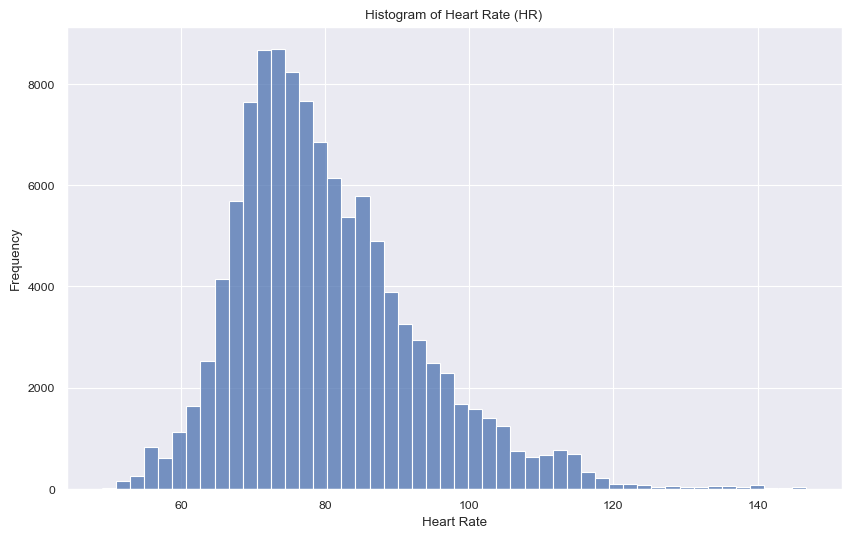

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["HR"], bins=50)
plt.title("Histogram of Heart Rate (HR)")
plt.xlabel("Heart Rate")
plt.ylabel("Frequency")
plt.savefig("../../datasets/stress/raw/plots/stress_hist.png", dpi=600, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

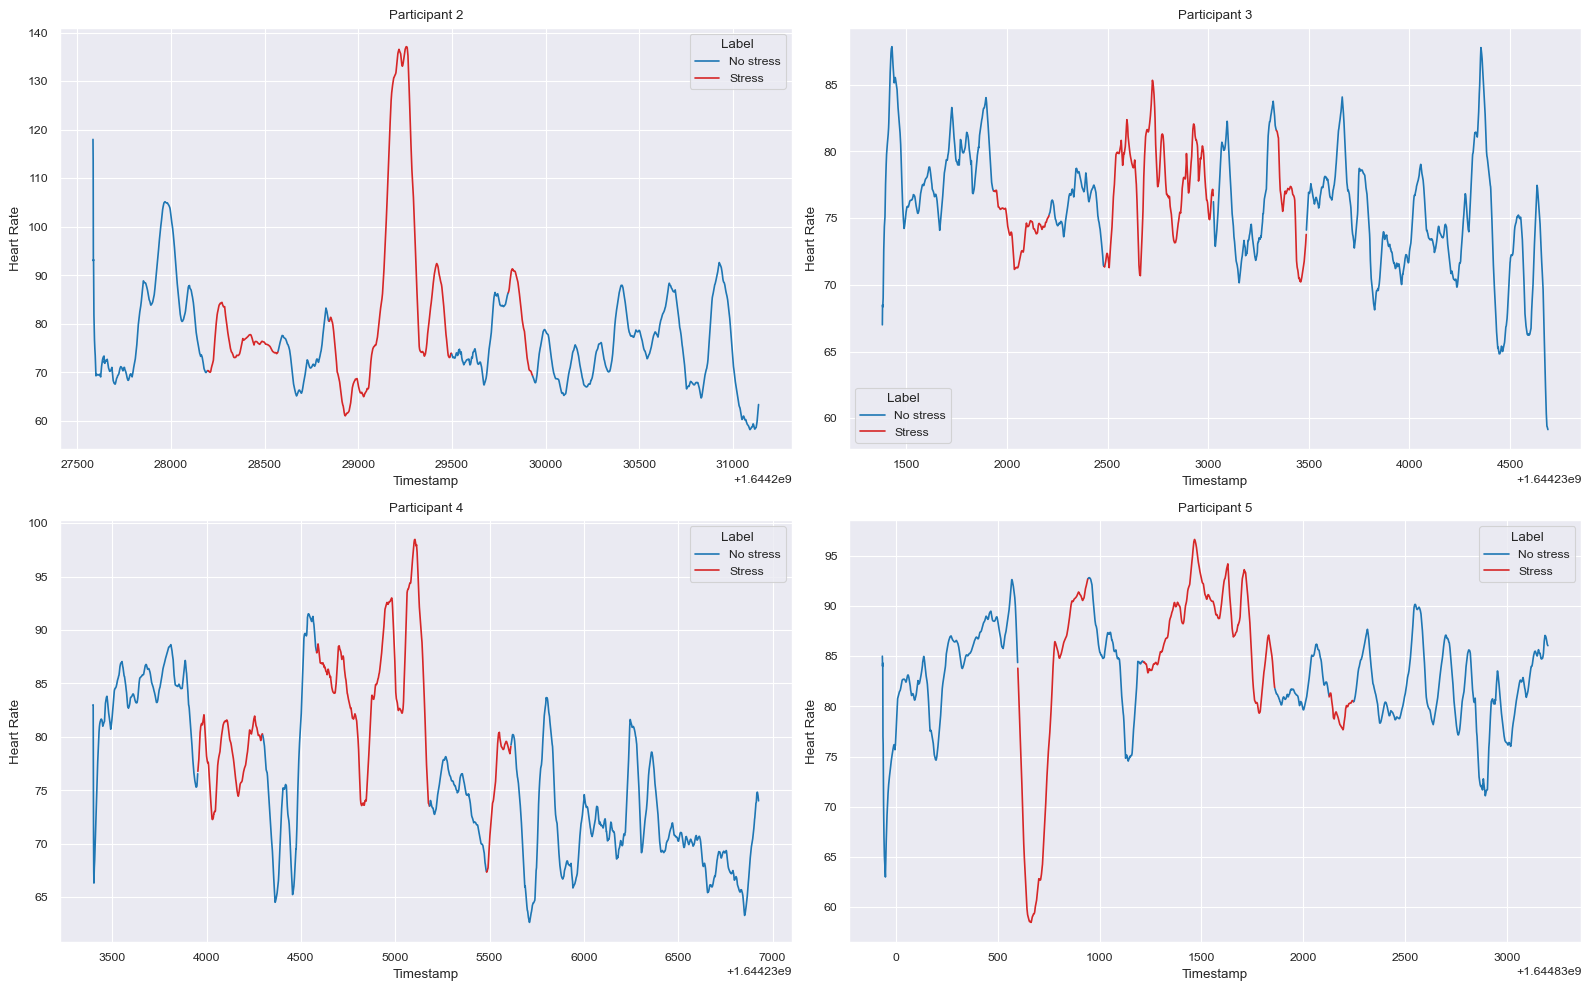

In [40]:
plt.figure(figsize=(12, 6))

color_map = {0: '#1f77b4', 1: '#d62728'}
label_map = {0: 'No stress', 1: 'Stress'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
participant_ids = sorted(df['Participant'].unique())[:4]

for ax, pid in zip(axes.flat, participant_ids):
    participant_data = df[df['Participant'] == pid].reset_index(drop=True)
    segments = []
    start_idx = 0
    for i in range(1, len(participant_data)):
        if participant_data.loc[i, 'Label'] != participant_data.loc[i-1, 'Label']:
            segments.append((start_idx, i))
            start_idx = i
    segments.append((start_idx, len(participant_data)))
    added_labels = set()
    for start, end in segments:
        segment = participant_data.iloc[start:end]
        label = segment['Label'].iloc[0]
        display_label = label_map[label]
        sns.lineplot(
            data=segment,
            x='Time(sec)',
            y='HR',
            color=color_map[label],
            label=display_label if display_label not in added_labels else None,
            ax=ax
        )
        added_labels.add(display_label)
    ax.set_title(f'Participant {pid}')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Heart Rate')
    ax.legend(title='Label')

plt.tight_layout()
plt.savefig("../../datasets/stress/raw/plots/hr_timeseries_4.png", dpi=600, bbox_inches="tight")
plt.show()

## RR

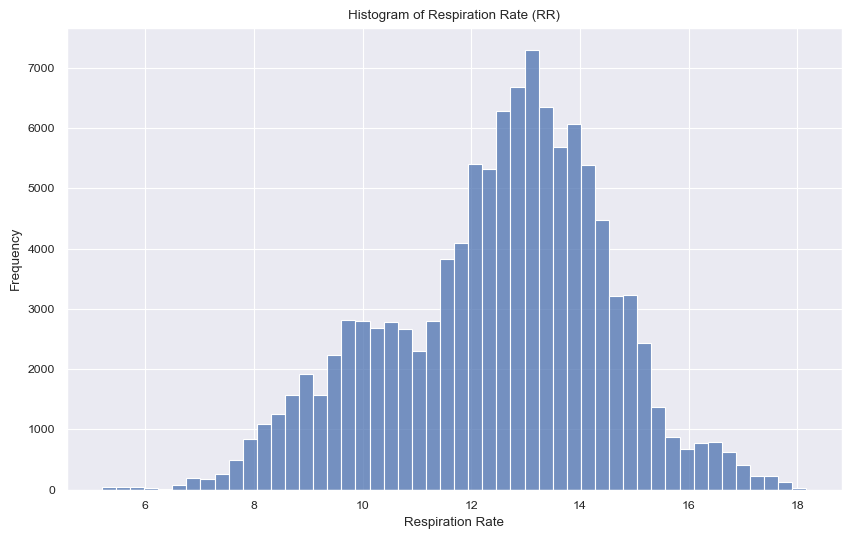

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["respr"], bins=50)
plt.title("Histogram of Respiration Rate (RR)")
plt.xlabel("Respiration Rate")
plt.ylabel("Frequency")
plt.savefig("../../datasets/stress/raw/plots/rr_hist.png", dpi=600, bbox_inches="tight")
plt.show()

<Figure size 1200x600 with 0 Axes>

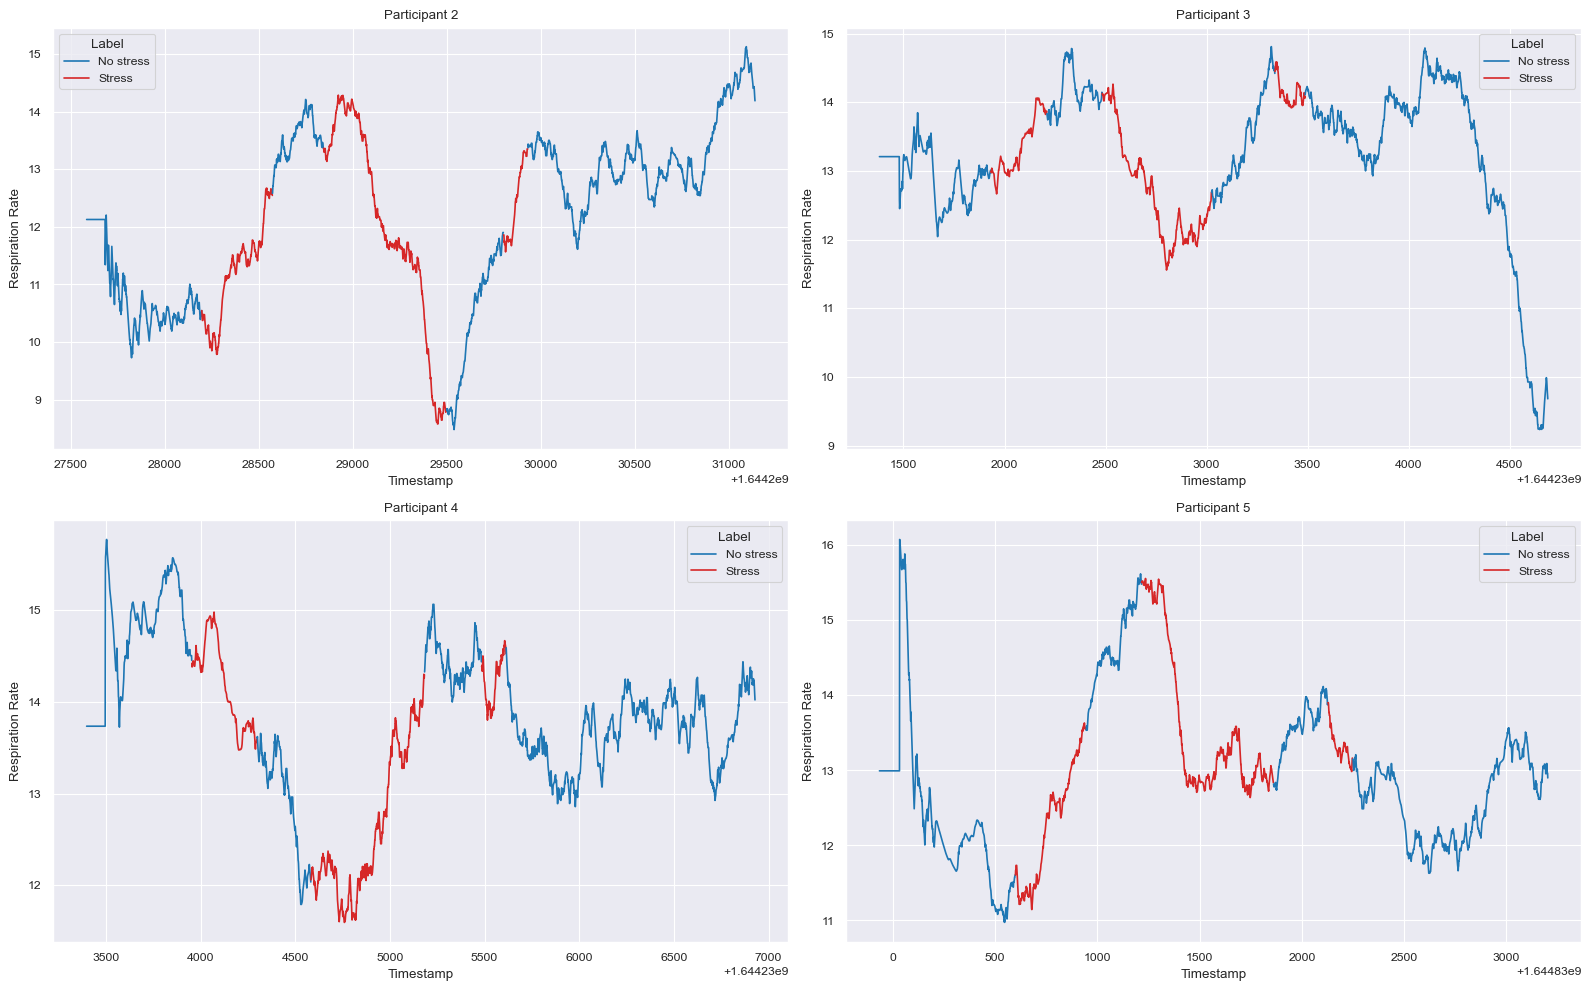

In [46]:
plt.figure(figsize=(12, 6))

color_map = {0: '#1f77b4', 1: '#d62728'}
label_map = {0: 'No stress', 1: 'Stress'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
participant_ids = sorted(df['Participant'].unique())[:4]

for ax, pid in zip(axes.flat, participant_ids):
    participant_data = df[df['Participant'] == pid].reset_index(drop=True)
    segments = []
    start_idx = 0
    for i in range(1, len(participant_data)):
        if participant_data.loc[i, 'Label'] != participant_data.loc[i-1, 'Label']:
            segments.append((start_idx, i))
            start_idx = i
    segments.append((start_idx, len(participant_data)))
    added_labels = set()
    for start, end in segments:
        segment = participant_data.iloc[start:end]
        label = segment['Label'].iloc[0]
        display_label = label_map[label]
        sns.lineplot(
            data=segment,
            x='Time(sec)',
            y='respr',
            color=color_map[label],
            label=display_label if display_label not in added_labels else None,
            ax=ax
        )
        added_labels.add(display_label)
    ax.set_title(f'Participant {pid}')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Respiration Rate')
    ax.legend(title='Label')

plt.tight_layout()
plt.savefig("../../datasets/stress/raw/plots/dataset_1_rr_timeseries_4.png", dpi=600, bbox_inches="tight")
plt.show()

# Nurse Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../../datasets/nurse/raw/nurse_no_features.csv", engine="pyarrow")

In [4]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report")

In [5]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:25<00:00,  2.83s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
df.describe()

,X,Y,Z,EDA,HR,TEMP,datetime,label
count,1.150905e+07,1.150905e+07,1.150905e+07,1.150905e+07,1.150905e+07,1.150905e+07,11509051,1.150905e+07
mean,-2.823775e+01,-9.091032e-01,2.382449e+01,3.502127e+00,8.576090e+01,3.223435e+01,2020-08-01 00:55:33.359851264,1.554202e+00
min,-1.280000e+02,-1.280000e+02,-1.280000e+02,0.000000e+00,5.100000e+01,2.409000e+01,2020-04-14 22:31:00,0.000000e+00
25%,-5.200000e+01,-1.900000e+01,4.000000e+00,2.242060e-01,7.672000e+01,3.019000e+01,2020-06-25 20:39:14.390625024,1.000000e+00
50%,-3.300000e+01,1.000000e+00,2.500000e+01,1.157407e+00,8.390000e+01,3.257000e+01,2020-07-06 18:24:36.750000128,2.000000e+00
75%,-1.400000e+01,1.700000e+01,4.900000e+01,4.077436e+00,9.310000e+01,3.425000e+01,2020-08-06 20:39:26.953124864,2.000000e+00
max,1.270000e+02,1.270000e+02,1.270000e+02,5.976071e+01,1.802300e+02,3.659000e+01,2020-12-13 08:01:00,2.000000e+00
std,3.142310e+01,3.343382e+01,2.985317e+01,5.656541e+00,1.419642e+01,2.260516e+00,NaN,7.891827e-01


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 9 columns):
 #   Column    Dtype         
---  ------    -----         
 0   X         float64       
 1   Y         float64       
 2   Z         float64       
 3   EDA       float64       
 4   HR        float64       
 5   TEMP      float64       
 6   id        object        
 7   datetime  datetime64[ns]
 8   label     float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 790.3+ MB


## HR

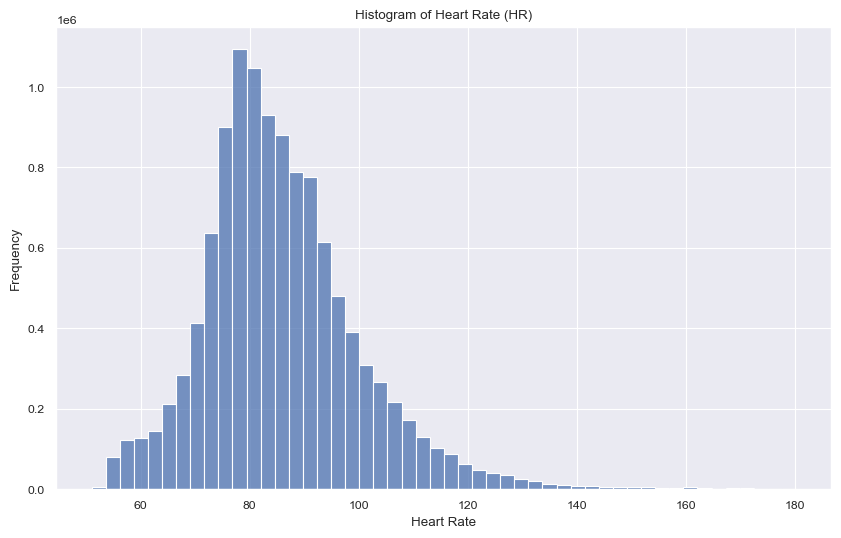

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["HR"], bins=50)
plt.title("Histogram of Heart Rate (HR)")
plt.xlabel("Heart Rate")
plt.ylabel("Frequency")
plt.savefig("../../datasets/nurse/raw/plots/stress_hist.png", dpi=600, bbox_inches="tight")
plt.show()

## EDA

In [8]:
df[df["EDA"] != 0].min()

X                        -128.0
Y                        -128.0
Z                        -128.0
EDA                    0.000267
HR                         51.0
TEMP                      24.09
id                           15
datetime    2020-04-14 22:31:00
label                       0.0
dtype: object

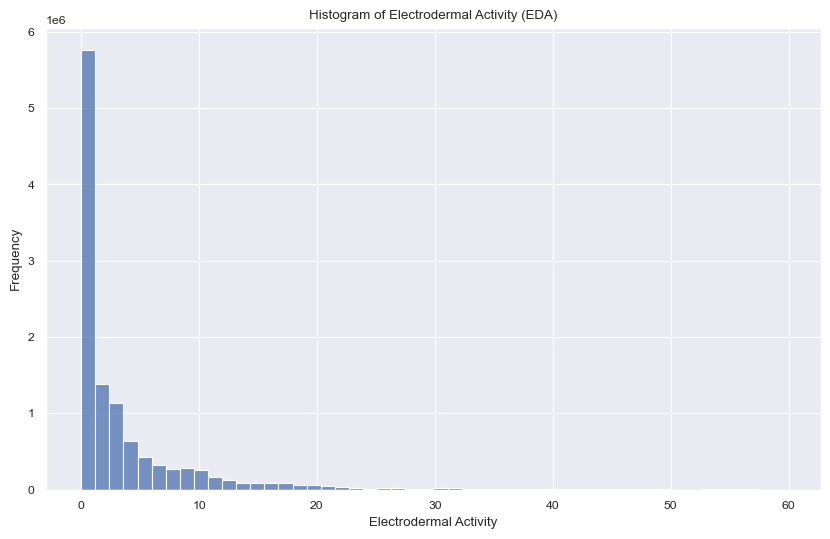

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df[df["EDA"] != 0]["EDA"], bins=50)
plt.title("Histogram of Electrodermal Activity (EDA)")
plt.xlabel("Electrodermal Activity")
plt.ylabel("Frequency")
plt.savefig("../../datasets/nurse/raw/plots/dataset_2_eda_hist.png", dpi=600, bbox_inches="tight")
plt.show()

## TEMP

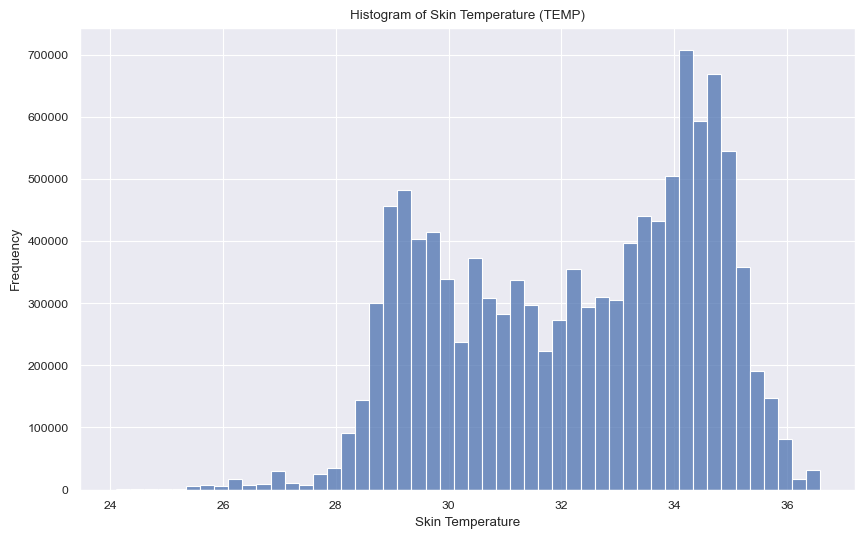

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["TEMP"], bins=50)
plt.title("Histogram of Skin Temperature (TEMP)")
plt.xlabel("Skin Temperature")
plt.ylabel("Frequency")
plt.savefig("../../datasets/nurse/raw/plots/dataset_2_st_hist.png", dpi=600, bbox_inches="tight")
plt.show()

## Acc

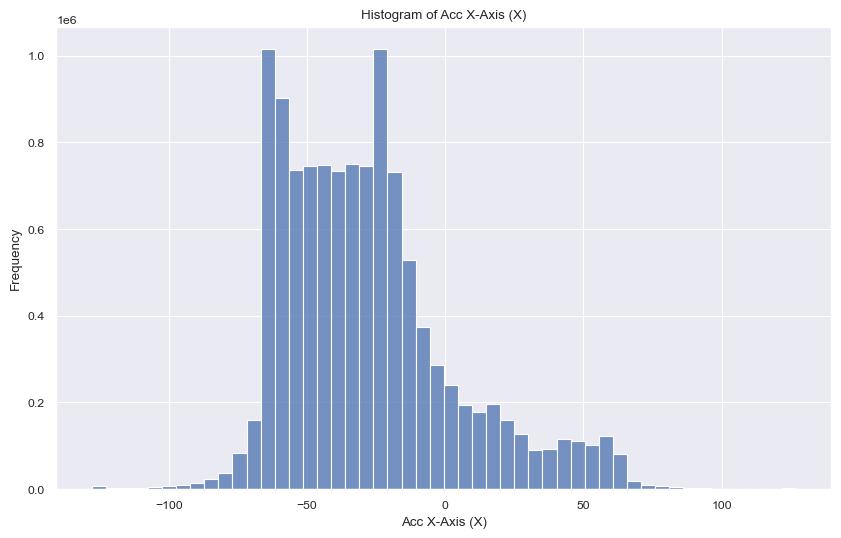

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["X"], bins=50)
plt.title("Histogram of Acc X-Axis (X)")
plt.xlabel("Acc X-Axis (X)")
plt.ylabel("Frequency")
plt.savefig("../../datasets/nurse/raw/plots/dataset_2_acc_x_hist.png", dpi=600, bbox_inches="tight")
plt.show()

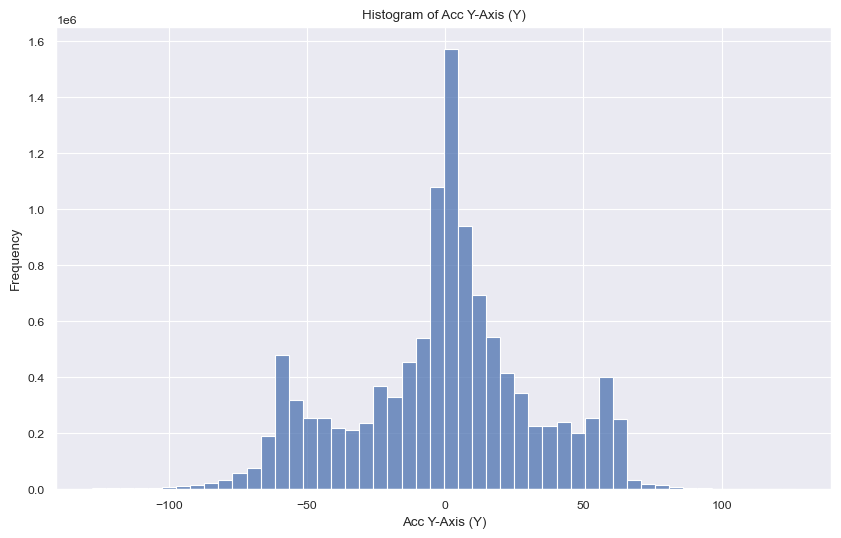

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["Y"], bins=50)
plt.title("Histogram of Acc Y-Axis (Y)")
plt.xlabel("Acc Y-Axis (Y)")
plt.ylabel("Frequency")
plt.savefig("../../datasets/nurse/raw/plots/dataset_2_acc_y_hist.png", dpi=600, bbox_inches="tight")
plt.show()

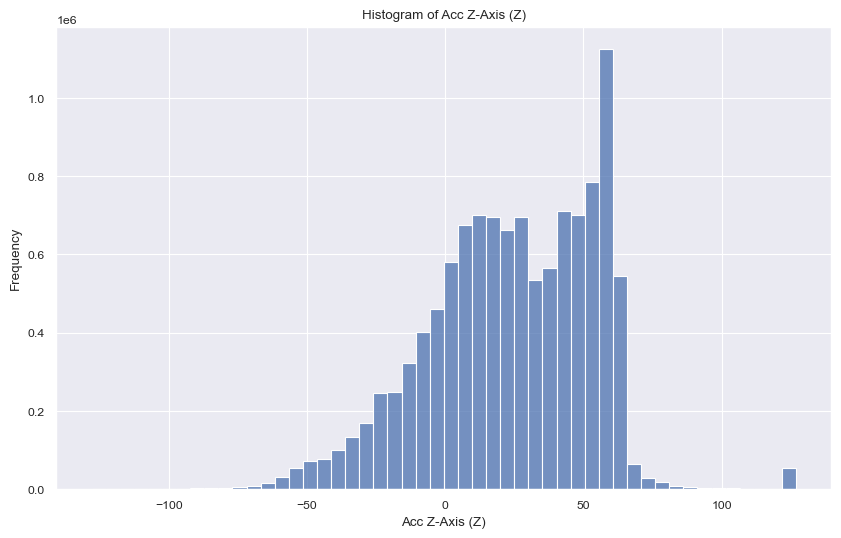

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.histplot(df["Z"], bins=50)
plt.title("Histogram of Acc Z-Axis (Z)")
plt.xlabel("Acc Z-Axis (Z)")
plt.ylabel("Frequency")
plt.savefig("../../datasets/nurse/raw/plots/dataset_2_acc_z_hist.png", dpi=600, bbox_inches="tight")
plt.show()

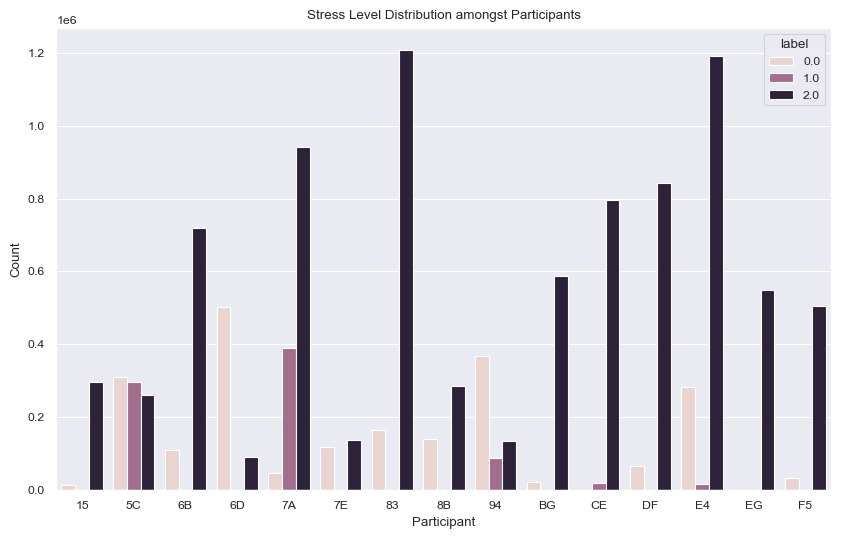

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper")

plt.figure(figsize=(10, 6))
sns.countplot(x=df["id"], hue=df["label"])
plt.title("Stress Level Distribution amongst Participants")
plt.xlabel("Participant")
plt.ylabel("Count")
plt.savefig("../../datasets/nurse/raw/plots/dataset_2_stress_hist.png", dpi=600, bbox_inches="tight")
plt.show()